In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 4.4 MB/s eta 0:00:00


In [56]:
import zipfile

zip_path = "/content/drive/MyDrive/signature_detection_dataset/reference_images.zip"

extract_path = "/content/reference_images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted Successfully")

Extracted Successfully


In [57]:
# ==========================================
# MOUNT DRIVE
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

# ==========================================
# EXTRACT REFERENCE IMAGES
# ==========================================

import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/signature_detection_dataset/reference_images.zip"

EXTRACT_PATH = "/content/reference_images"

if not os.path.exists(EXTRACT_PATH):

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_PATH)

print("Reference Images Extracted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reference Images Extracted


In [58]:
import os
print(os.listdir("/content/reference_images"))

['Reference_Images']


In [60]:
import os

YOLO_MODEL = "/content/drive/MyDrive/signature_yolo_best.pt"
SNN_MODEL = "/content/drive/MyDrive/signature_snn_model.h5"
REFERENCE_ROOT = "/content/reference_images/Reference_Images"

print("YOLO:", os.path.exists(YOLO_MODEL))
print("SNN :", os.path.exists(SNN_MODEL))
print("REF :", os.path.exists(REFERENCE_ROOT))

print("\nReference folders:")
print(os.listdir(REFERENCE_ROOT))

YOLO: True
SNN : True
REF : True

Reference folders:
['Person7', 'Person1', 'Person2', 'Person6', 'Person3', 'Person5', 'Person4']


Loading YOLO...
Loading SNN...
Models Loaded Successfully

Available Persons:
['Person1', 'Person2', 'Person3', 'Person4', 'Person5', 'Person6', 'Person7']

Enter Person Name (Example: Person1): Person3
Enter Test Image Path: /content/drive/MyDrive/signature_detection_dataset/signtest2.jpeg

Cropping signature...
Crop Shape: (167, 466, 3)
Comparing against 8 reference signatures...
Img1.jpeg -> 0.005216288845986128
Img2.jpeg -> 0.38973239064216614
Img3.jpeg -> 0.0009913069661706686
Img4.jpeg -> 0.9993602633476257
Img5.jpeg -> 0.8325993418693542
Img6.jpeg -> 0.00025681708939373493
Img7.jpeg -> 0.0019220683025196195
Img8.jpeg -> 0.962229311466217

Average Similarity: 0.399
RESULT: GENUINE SIGNATURE


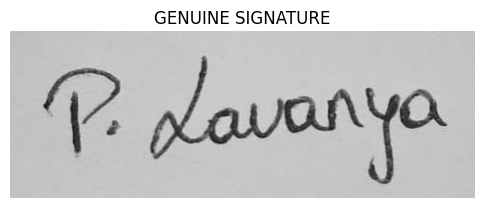

In [74]:
# ============================================================
# SIGNATURE VERIFICATION PIPELINE
# YOLO + SNN
# ============================================================

!pip install ultralytics -q

import os
import cv2
import numpy as np
import tensorflow as tf
from ultralytics import YOLO
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# ============================================================
# PATHS
# ============================================================

YOLO_MODEL = "/content/drive/MyDrive/signature_yolo_best.pt"
SNN_MODEL = "/content/drive/MyDrive/signature_snn_model.h5"
REFERENCE_ROOT = "/content/reference_images/Reference_Images"

# ============================================================
# CUSTOM FUNCTIONS FOR SNN
# ============================================================

def abs_diff(vects):
    x, y = vects
    return tf.abs(x - y)

# ============================================================
# LOAD MODELS
# ============================================================

print("Loading YOLO...")
yolo_model = YOLO(YOLO_MODEL)

print("Loading SNN...")
snn_model = load_model(SNN_MODEL, custom_objects={'abs_diff': abs_diff}, compile=False)

print("Models Loaded Successfully")

# ============================================================
# PREPROCESS FUNCTION
# ============================================================

def preprocess_image(image_path):

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise Exception(f"Cannot read image: {image_path}")

    img = cv2.resize(img, (220,155))
    img = img / 255.0
    img = img.reshape(155,220,1)

    return img.astype(np.float32)

# ============================================================
# SIGNATURE CROP USING YOLO
# ============================================================
def crop_signature(image_path):

    results = yolo_model.predict(
        image_path,
        conf=0.01,
        verbose=False
    )

    img = cv2.imread(image_path)

    if img is None:
        raise Exception("Image cannot be read")

    boxes = results[0].boxes

    if len(boxes) == 0:
        raise Exception("No signature detected")

    best_box = boxes[0]

    x1,y1,x2,y2 = map(int, best_box.xyxy[0])

    crop = img[y1:y2, x1:x2]
    print("Crop Shape:", crop.shape)


    # IMPORTANT
    crop = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)

    save_path = "/content/cropped_signature.jpg"

    cv2.imwrite(save_path, crop)

    return save_path
# ============================================================
# COMPARE WITH ALL REFERENCE IMAGES
# ============================================================

def verify_signature(person_name, test_image_path):

    person_folder = os.path.join(
        REFERENCE_ROOT,
        person_name
    )

    if not os.path.exists(person_folder):
        raise Exception(
            f"{person_name} folder not found"
        )

    print("\nCropping signature...")
    cropped_path = crop_signature(test_image_path)

    test_img = preprocess_image(cropped_path)

    scores = []

    reference_files = sorted(
        os.listdir(person_folder)
    )

    print(
        f"Comparing against {len(reference_files)} reference signatures..."
    )

    for file in reference_files:

        ref_path = os.path.join(
            person_folder,
            file
        )

        ref_img = preprocess_image(ref_path)

        prediction = snn_model.predict(
            [
                np.expand_dims(test_img,0),
                np.expand_dims(ref_img,0)
            ],
            verbose=0
        )

        score = float(prediction[0][0])

        print(f"{file} -> {score}")

        scores.append(score)


    final_score = np.mean(scores)

    print("\n========================")
    print("Average Similarity:", round(final_score,4))

    threshold = 0.65

    if final_score <= threshold:
        result = "GENUINE SIGNATURE"
    else:
        result = "FORGED SIGNATURE"

    print("RESULT:", result)
    print("========================")

    return final_score, result, cropped_path

# ============================================================
# USER INPUT
# ============================================================

print("\nAvailable Persons:")
print(sorted(os.listdir(REFERENCE_ROOT)))

person_name = input(
    "\nEnter Person Name (Example: Person1): "
)

test_image = input(
    "Enter Test Image Path: "
)

# ============================================================
# RUN VERIFICATION
# ============================================================

score, result, cropped = verify_signature(
    person_name,
    test_image
)

# ============================================================
# SHOW CROPPED SIGNATURE
# ============================================================

img = cv2.imread(cropped)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,3))
plt.imshow(img)
plt.title(result)
plt.axis("off")
plt.show()